In [1]:
%pylab inline
import scanpy as sc
import pandas as pd
import seaborn as sns
import numpy as np
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt

rcParams['pdf.fonttype']=42 # in order to save fonttype in AI
rcParams['ps.fonttype']=42

import warnings
warnings.filterwarnings("ignore")

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


# Loading data...

In [2]:
# Load Tasic data
ad_tasic = sc.read('./TsicData/Tasic_mice_filtered.h5')

In [3]:
ad_tasic

AnnData object with n_obs × n_vars = 23178 × 39281
    obs: 'title', 'source_name', 'organism', 'donor_id', 'donor_sex', 'donor_genotype', 'injection_type', 'injection_target', 'injected_material', 'dissected_region', 'dissected_layer', 'facs_gating', 'facs_date', 'rna_amplification_set', 'sequencing_tube', 'sequencing_batch', 'sequencing_qc_pass_fail', 'cell_class', 'cell_subclass', 'cell_cluster', 'molecule', 'SRA_Run', 'GEO_Sample', 'GEO_Sample_Title', 'n_counts'
    var: 'n_cells'
    layers: 'counts'

In [4]:
ad_tasic = ad_tasic[ad_tasic.obs['cell_class'].isin(['GABAergic'])]
ad_tasic = ad_tasic[~ad_tasic.obs['cell_subclass'].isin(['nan'])]

In [5]:
sc.tl.pca(ad_tasic, svd_solver='arpack')
sc.pp.neighbors(ad_tasic, n_neighbors=10, n_pcs=40)
sc.tl.umap(ad_tasic,random_state=44)

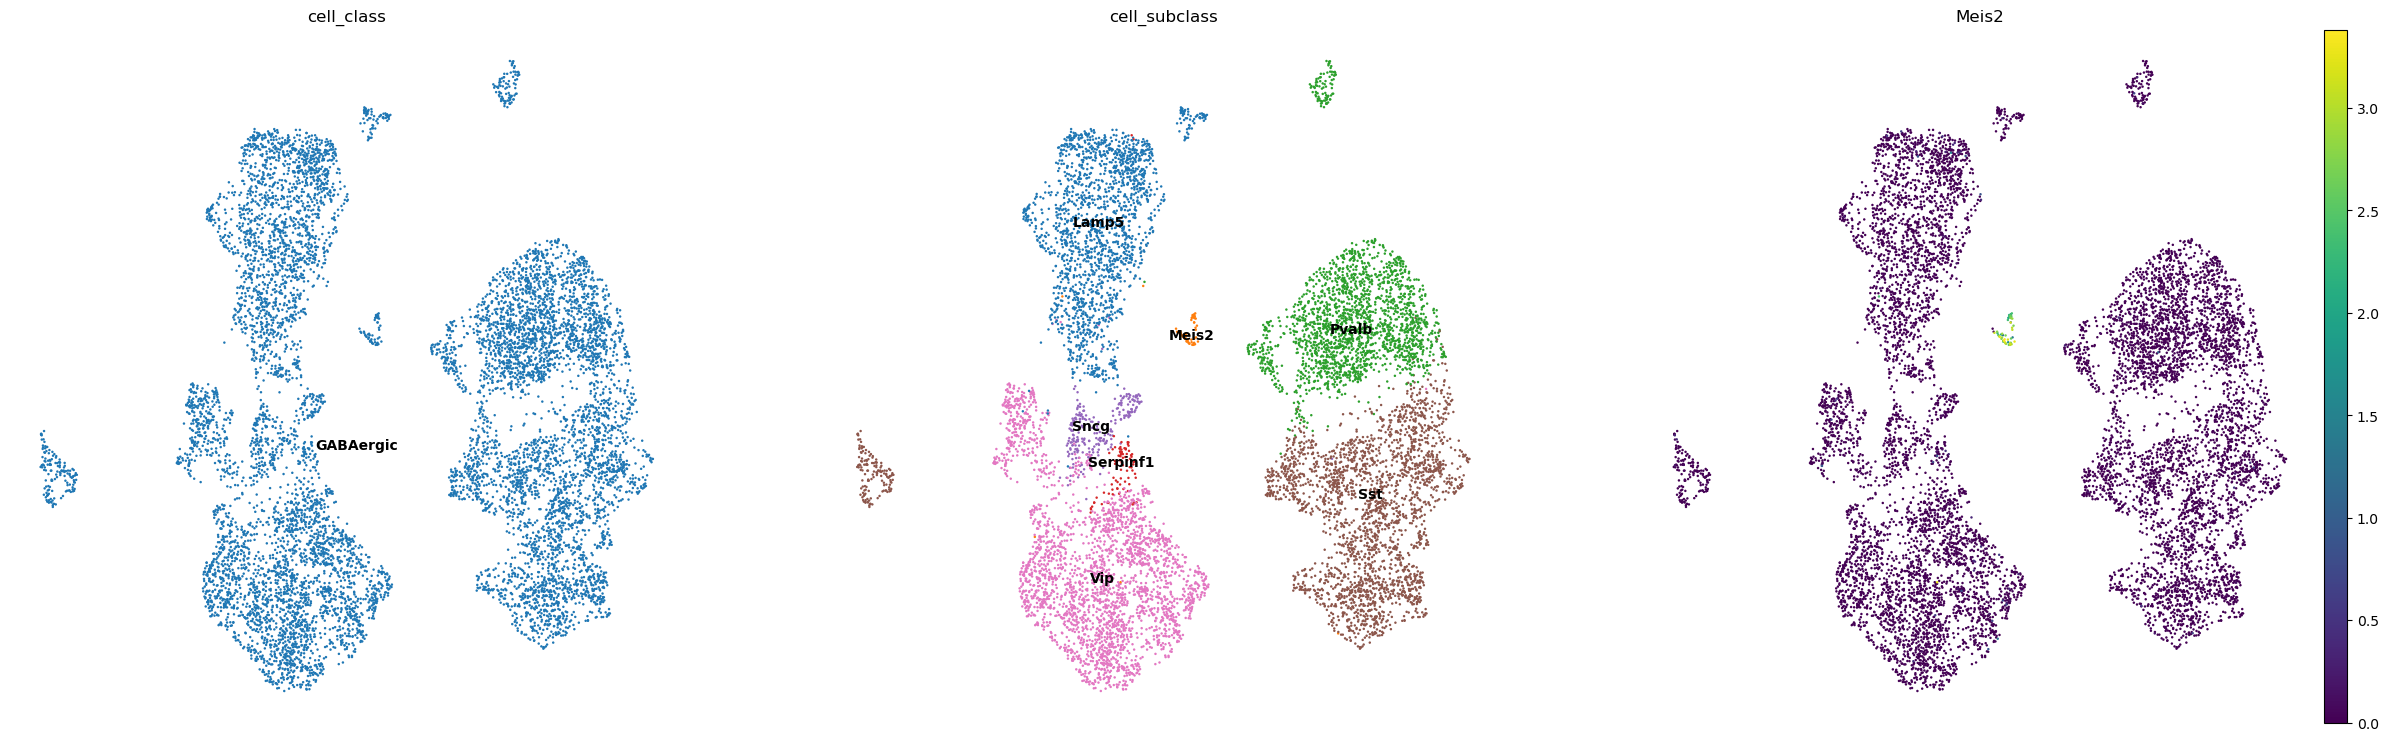

In [6]:
figsize(9,9)
sc.pl.umap(ad_tasic,color=['cell_class','cell_subclass','Meis2'],frameon=False,legend_loc='on data')

In [7]:
# ===========mapping mouse gene names to monkey gene names ====================

# load data from file. 
gene_mus2mk = pd.read_csv('../refGenesXspecies/mouse2monkey.csv',sep='\t')
# remove the nans in mouse gene names and mobkey gene names.
gene_mus2mk = gene_mus2mk[~gene_mus2mk['Crab-eating macaque gene name'].isna() & ~gene_mus2mk['Gene name'].isna()]
# remove the duplicates in monkey gene names
gene_mus2mk = gene_mus2mk.loc[gene_mus2mk['Crab-eating macaque gene name'].drop_duplicates(keep='first').index,]

# crate a gene name dict of gene names between mouse and monkey.
gene_dict = dict(zip(gene_mus2mk['Gene name'],gene_mus2mk['Crab-eating macaque gene name']))

# mapping mouse gene names to monkey gene names
ad_index = ad_tasic.var_names
new_index = ad_index.map(lambda x: gene_dict.get(x, 'NA'))

ad_tasic.var_names = new_index

In [8]:
ad_tasic = ad_tasic[:,ad_tasic.var_names !='NA']

In [9]:
ad_ins = sc.read('../data_h5/Insular_sorted_clusters.h5ad')
ad_ins

AnnData object with n_obs × n_vars = 122663 × 19944
    obs: 'batch', 'doublet_score', 'predicted_doublets', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'Sex', 'Sample', 'cellTypeID', 'cellTypeLabel', 'cell_subtypeID', 'cell_subtypeLabels', 'cellTypeID_2', 'cellType_labels_2', 'sampleLayers'
    var: 'gene_ids', 'feature_types', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'Sample_colors', 'Sex_colors', 'batch_colors', 'cellTypeID_2_colors', 'cellTypeID_colors', 'cellTypeLabel_colors', 'cellType_labels_2_colors', 'cell_subtypeID_colors', 'cell_subtypeLabels_colors', 'dendrogram_cellTypeLabel', 'dendrogram_cellType_labels_2', 'dendrogram_cell_subtypeLabels', 'hvg', 'neighbors', 'pca', 'rank_genes_groups', 'sampleLayers_colors', 'tsne', 'umap'
    obsm: 'X_harmonypca', 'X_pca', 'X_tsne', 'X_umap', 'X_umapharmony', '

In [10]:
ad_inhib = ad_ins[ad_ins.obs['cellTypeID'].isin(['4','6'])]

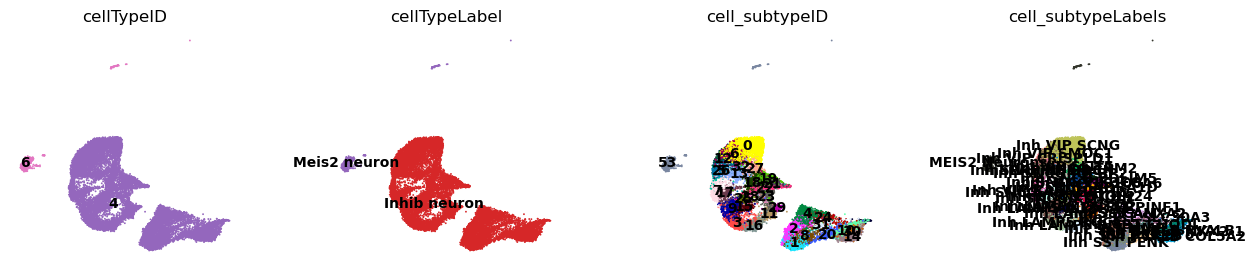

In [11]:
figsize(3,3)
sc.pl.umap(ad_inhib,color=['cellTypeID','cellTypeLabel','cell_subtypeID','cell_subtypeLabels'],frameon=False,legend_loc='on data')

### build new scanpy AnnData objects and combine...

In [12]:
ad_mus = sc.AnnData( ad_tasic.X, dict(obs_names=ad_tasic.obs_names),dict(var_names=ad_tasic.var_names) )
ad_mus.obs['species'] = 'mus'
ad_mus.obs['sequencing_batch_mus'] = ad_tasic.obs['sequencing_batch']
ad_mus.obs['cell_class'] = ad_tasic.obs['cell_class']
ad_mus.obs['cell_subclass'] = ad_tasic.obs['cell_subclass']

In [13]:
ad_mk = sc.AnnData( ad_inhib.X, dict(obs_names=ad_inhib.obs_names),dict(var_names=ad_inhib.var_names) )
ad_mk.obs['species'] = 'mk'
ad_mk.obs['sequenceing_batch_mk'] = ad_inhib.obs['batch']
ad_mk.obs['cellTypeID'] = ad_inhib.obs['cellTypeID']
ad_mk.obs['cellTypeLabel'] = ad_inhib.obs['cellTypeLabel']
ad_mk.obs['cell_subtypeID'] = ad_inhib.obs['cell_subtypeID']
ad_mk.obs['cell_subtypeLabels'] = ad_inhib.obs['cell_subtypeLabels']

In [14]:
adata = ad_mus.concatenate(ad_mk, index_unique=None)
adata

AnnData object with n_obs × n_vars = 26545 × 13619
    obs: 'species', 'sequencing_batch_mus', 'cell_class', 'cell_subclass', 'sequenceing_batch_mk', 'cellTypeID', 'cellTypeLabel', 'cell_subtypeID', 'cell_subtypeLabels', 'batch'

In [15]:
adata.write_h5ad('./temData/merged_tasic_ins.h5ad')

In [16]:
del([ad_tasic,ad_ins,ad_mus,ad_mk])

### run scanpy analysis pipeline.

In [17]:
sc.pp.calculate_qc_metrics(adata, percent_top=None, log1p=False, inplace=True)
sc.pp.highly_variable_genes(
    adata,
    batch_key="batch",
    flavor="seurat",
    n_top_genes=2500,
    subset=True,
    min_mean=0.015, 
    max_mean=10,
    min_disp=0.05
)

In [18]:
adata = adata[:, adata.var.highly_variable]
sc.pp.regress_out(adata, ['total_counts'])
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, svd_solver='arpack')
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
sc.tl.umap(adata,random_state=44)

In [19]:
adata

AnnData object with n_obs × n_vars = 26545 × 2500
    obs: 'species', 'sequencing_batch_mus', 'cell_class', 'cell_subclass', 'sequenceing_batch_mk', 'cellTypeID', 'cellTypeLabel', 'cell_subtypeID', 'cell_subtypeLabels', 'batch', 'n_genes_by_counts', 'total_counts'
    var: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mean', 'std'
    uns: 'hvg', 'pca', 'neighbors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

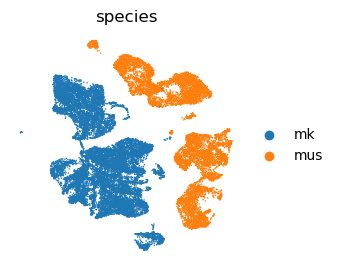

In [20]:
sc.pl.umap(adata,color='species',frameon=False,legend_loc='right margin')

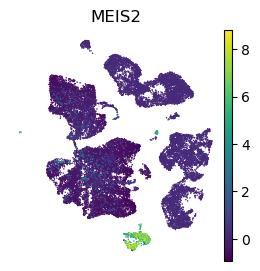

In [21]:
figsize(3,3)
sc.pl.umap(adata,color='MEIS2',frameon=False,legend_loc='right margin')

### remove the batch effects and integrate the data

In [22]:
import harmonypy as hm
ho = hm.run_harmony(adata.obsm['X_pca'], adata.obs, ['species','sequencing_batch_mus','sequenceing_batch_mk'],theta=10,max_iter_harmony=10,max_iter_kmeans=20)

adata.obsm['X_harmonypca'] = ho.Z_corr.T
sc.pp.neighbors(adata, use_rep='X_harmonypca',n_neighbors=10, n_pcs=40)

adata.obsm['X_umapraw'] = adata.obsm['X_umap']
sc.tl.umap(adata)
adata.obsm['X_umapharmony'] = adata.obsm['X_umap']

2025-08-17 00:24:18,256 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-08-17 00:24:26,491 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-08-17 00:24:26,593 - harmonypy - INFO - Iteration 1 of 10
2025-08-17 00:24:38,819 - harmonypy - INFO - Iteration 2 of 10
2025-08-17 00:24:51,156 - harmonypy - INFO - Iteration 3 of 10
2025-08-17 00:25:26,612 - harmonypy - INFO - Iteration 4 of 10
2025-08-17 00:25:35,679 - harmonypy - INFO - Iteration 5 of 10
2025-08-17 00:25:50,768 - harmonypy - INFO - Iteration 6 of 10
2025-08-17 00:26:05,754 - harmonypy - INFO - Iteration 7 of 10
2025-08-17 00:26:21,140 - harmonypy - INFO - Iteration 8 of 10
2025-08-17 00:26:39,186 - harmonypy - INFO - Converged after 8 iterations


In [23]:
adata

AnnData object with n_obs × n_vars = 26545 × 2500
    obs: 'species', 'sequencing_batch_mus', 'cell_class', 'cell_subclass', 'sequenceing_batch_mk', 'cellTypeID', 'cellTypeLabel', 'cell_subtypeID', 'cell_subtypeLabels', 'batch', 'n_genes_by_counts', 'total_counts'
    var: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mean', 'std'
    uns: 'hvg', 'pca', 'neighbors', 'umap', 'species_colors'
    obsm: 'X_pca', 'X_umap', 'X_harmonypca', 'X_umapraw', 'X_umapharmony'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

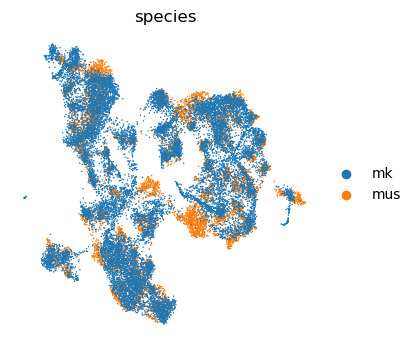

In [24]:
figsize(4,4)
sc.pl.umap(adata,color='species',frameon=False,legend_loc='right margin')

In [25]:
adata.obs['cell_subtypeLabels'].unique()

[NaN, 'Inh LAMP5 BMP2', 'Inh SST CHODL', 'Inh SST MME', 'Inh VIP SMOC1', ..., 'Inh SST SP5', 'Inh VIP SHISA8', 'Inh LAMP5 SERPINF1', 'Inh SNCG C1QL2', 'Inh VIP SLIT1']
Length: 35
Categories (34, object): ['Inh LAMP5 BCAM', 'Inh LAMP5 BMP2', 'Inh LAMP5 GSTM2', 'Inh LAMP5 IL13RA1', ..., 'Inh VIP SHISA8', 'Inh VIP SLIT1', 'Inh VIP SMOC1', 'MEIS2 Neurons']

In [26]:
SST = ['Inh SST ANXA2','Inh SST CHODL','Inh SST MME','Inh SST PENK','Inh SST PTK2B','Inh SST SLC30A3','Inh SST SP5']
PVALB = ['Inh PVALB COL5A2','Inh PVALB NKX2-1','Inh PVALB PVALB']
LAMP5 = ['Inh LAMP5 BCAM', 'Inh LAMP5 BMP2', 'Inh LAMP5 GSTM2', 'Inh LAMP5 IL13RA1', 'Inh LAMP5 RGCC', 'Inh LAMP5 SERPINF1']
SNCG = ['Inh SNCG ADRA1D','Inh SNCG ARHGAP18','Inh SNCG C1QL2','Inh SNCG CDH24','Inh SNCG IGFBP2','Inh SNCG KLHL13','Inh SNCG PDLIM5','Inh SNCG PIK3CG','Inh SNCG S100A6','Inh SNCG TPM2']
VIP = ['Inh VIP CRISPLD1','Inh VIP RASL10A','Inh VIP SCNG','Inh VIP SHISA8','Inh VIP SLIT1','Inh VIP SMOC1','Inh SERPINF1 DCN']

inhibType = adata.obs['cell_subtypeLabels'].astype('str')
inhibType[adata.obs['cell_subtypeLabels'].isin(SST)] = 'SST'
inhibType[adata.obs['cell_subtypeLabels'].isin(PVALB)] = 'PVALB'
inhibType[adata.obs['cell_subtypeLabels'].isin(LAMP5)] = 'LAMP5'
inhibType[adata.obs['cell_subtypeLabels'].isin(SNCG)] = 'SNCG'
inhibType[adata.obs['cell_subtypeLabels'].isin(VIP)] = 'VIP'

adata.obs['inhibType'] = inhibType.astype('category')

In [27]:
adata = adata[~adata.obs['cell_subtypeLabels'].isin(['Inh SERPINF1 DCN'])]

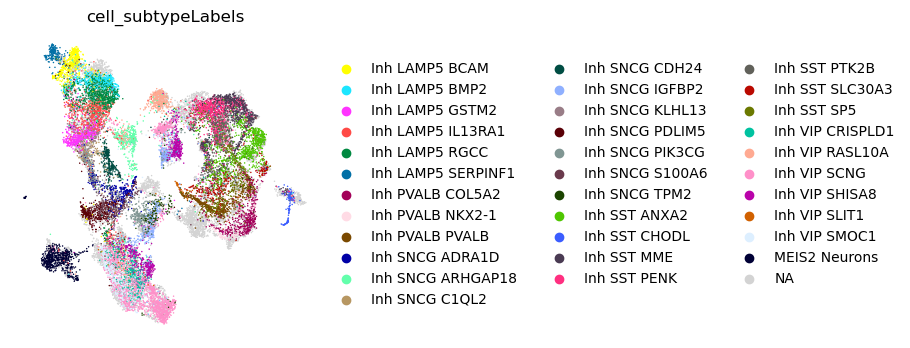

In [28]:
sc.pl.umap(adata,color=['cell_subtypeLabels'],frameon=False,legend_loc='right margin')

In [30]:
adata

AnnData object with n_obs × n_vars = 26300 × 2500
    obs: 'species', 'sequencing_batch_mus', 'cell_class', 'cell_subclass', 'sequenceing_batch_mk', 'cellTypeID', 'cellTypeLabel', 'cell_subtypeID', 'cell_subtypeLabels', 'batch', 'n_genes_by_counts', 'total_counts', 'inhibType'
    var: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mean', 'std'
    uns: 'hvg', 'pca', 'neighbors', 'umap', 'species_colors', 'cell_subtypeLabels_colors'
    obsm: 'X_pca', 'X_umap', 'X_harmonypca', 'X_umapraw', 'X_umapharmony'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

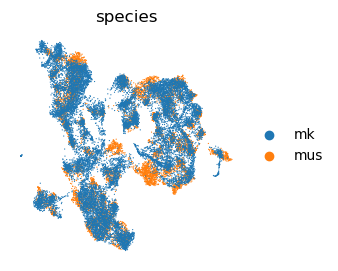

In [31]:
figsize(3,3)
sc.pl.umap(adata,color=['species'],frameon=False,legend_loc='right margin',s=3,save='umapSpecieCmp_meis2_mk_vs_mus.pdf')

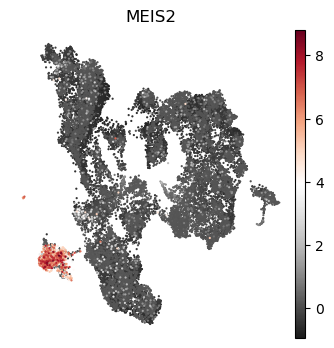

In [32]:
figsize(4,4)
sc.pl.umap(adata,color=['MEIS2'],frameon=False,legend_loc='right margin',cmap='RdGy_r',s=10)

In [33]:
# from matplotlib.colors import LinearSegmentedColormap

# # 定义从灰色到红色的颜色列表
# gray = (0.0, 0.0, 0.0)
# red = (0.8, 0.0, 0.0)
# # 创建色彩映射对象
# colors = np.linspace(0, 1, 10)[:, np.newaxis]
# cmap = gray + colors * (np.array(red) - np.array(gray))
# custom_cmap = LinearSegmentedColormap.from_list('brightGray2red', cmap)

# figsize(4,4)
# sc.pl.umap(adata,color=['MEIS2'],frameon=False,legend_loc='right margin',cmap=custom_cmap,s=10)

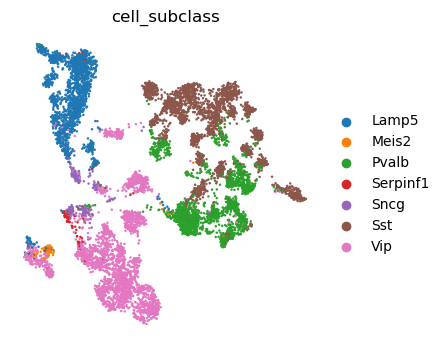

In [34]:
figsize(4,4)
sc.pl.umap(adata[adata.obs['species']=='mus'],color=['cell_subclass'],frameon=False,legend_loc='right margin',save='umapMusCellType_meis2_mk_vs_mus_1.pdf')

In [35]:
%pylab inline
import sys
sys.path.append('../tools')
from two_species_heatmap import *

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


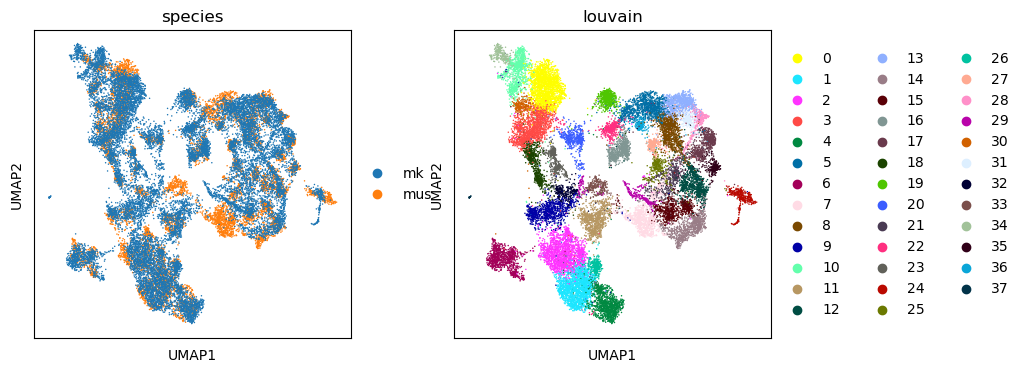

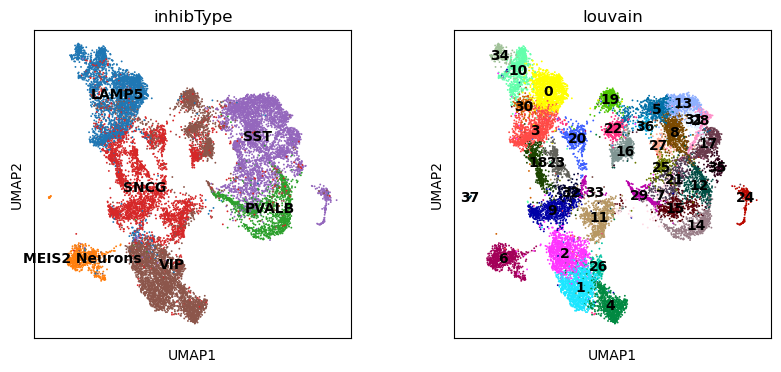

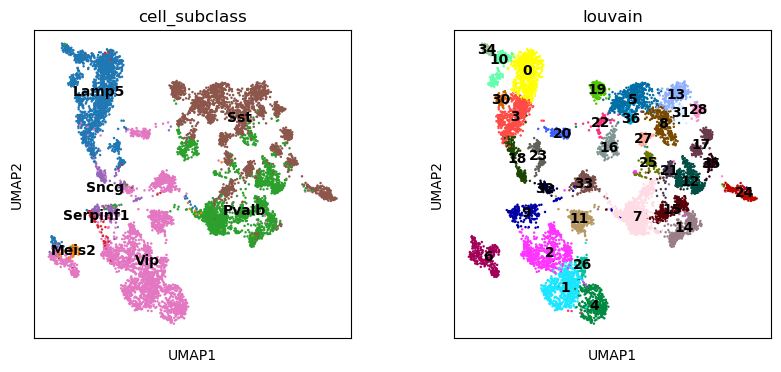

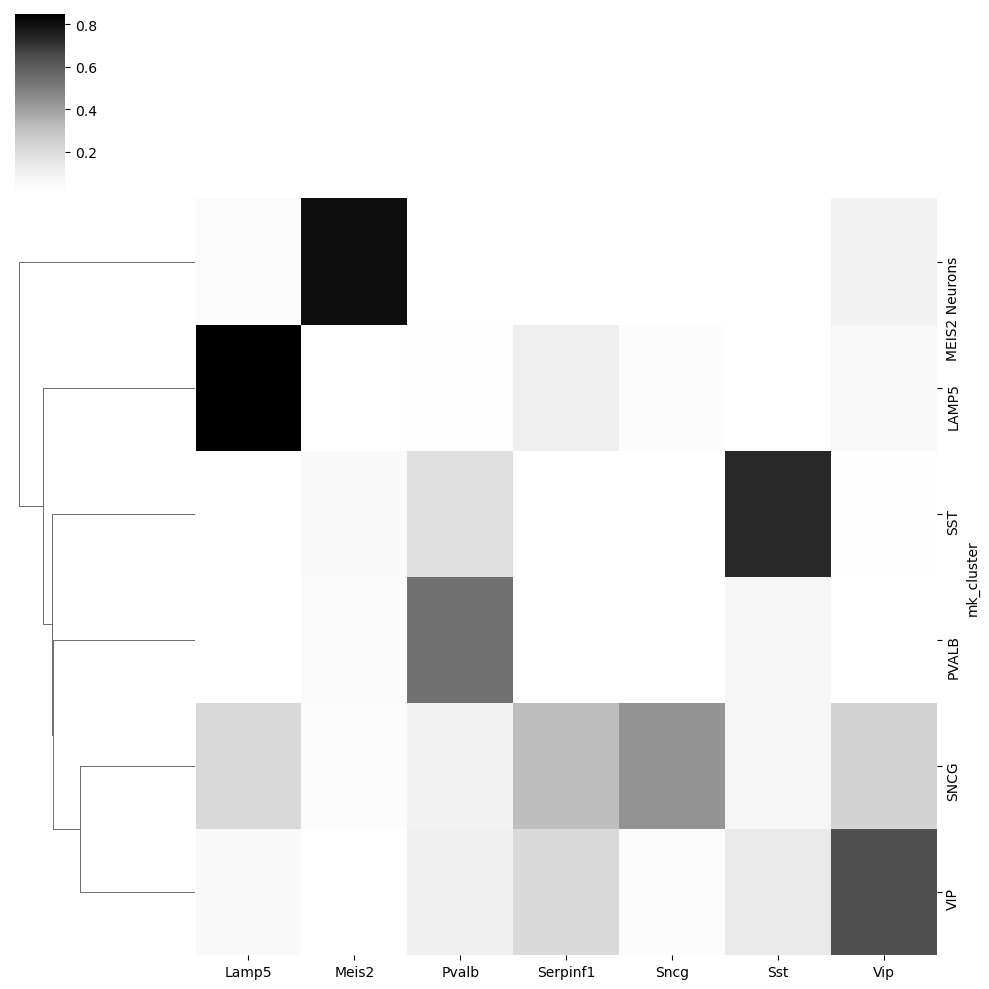

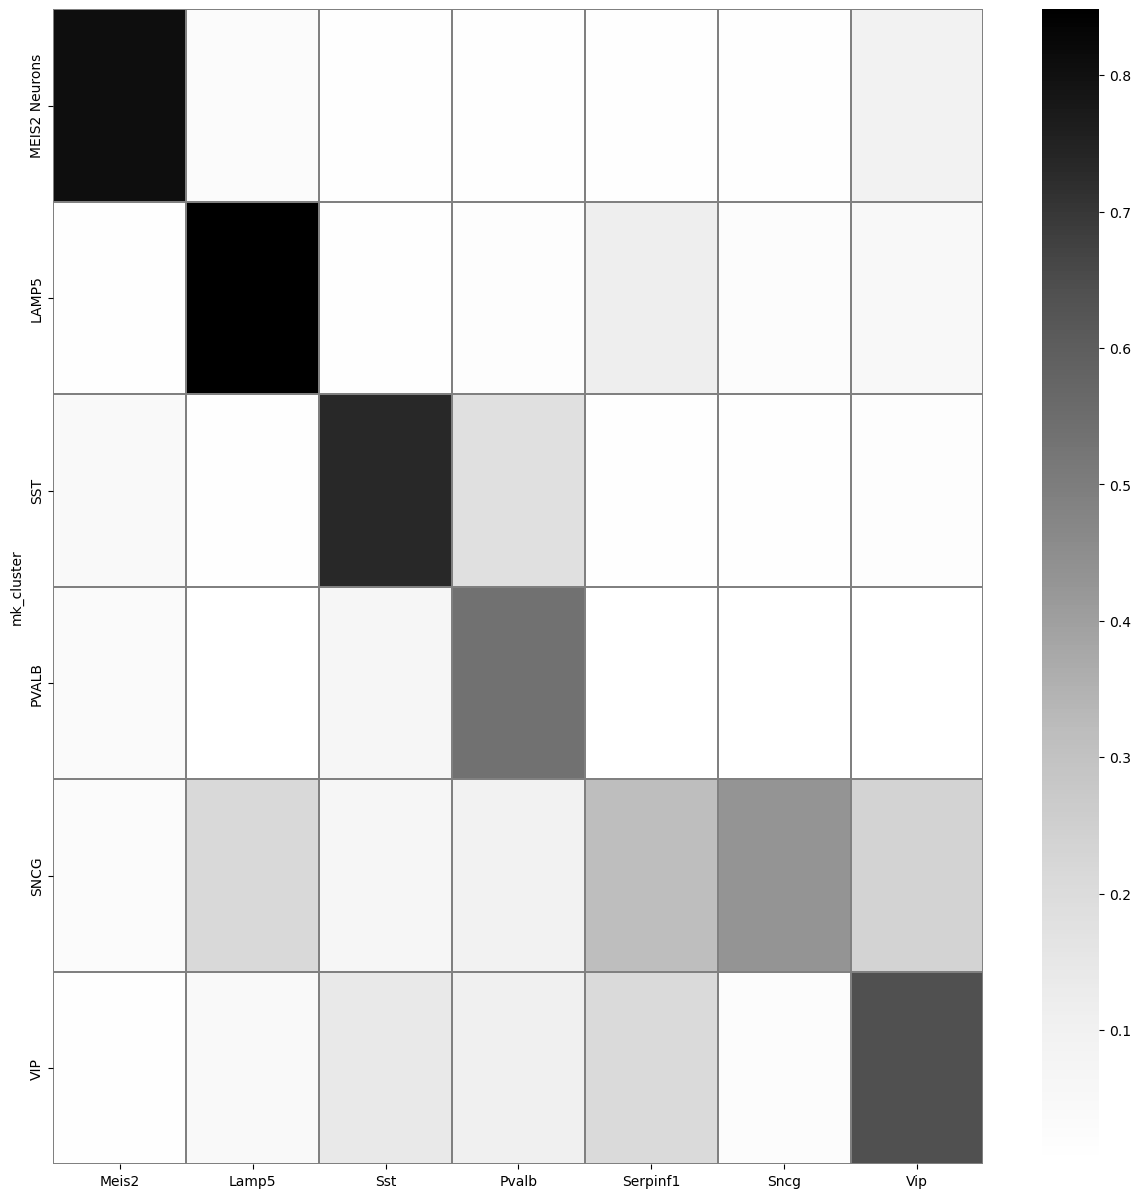

In [36]:
plot_cmpMatrix_mk_vs_hu_lovain_0_6 = two_species_heatmap(adata, species_1 = 'mk', species_2 = 'mus',\
                species_1_key = 'inhibType', species_2_key = 'cell_subclass',\
                louvain = 2.5)#,figure_path = './figs/neurons_heatmap_cmp.png')

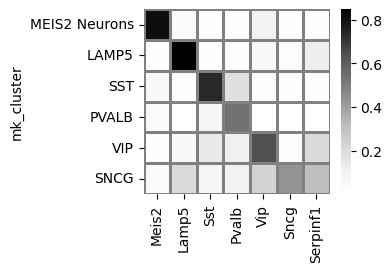

In [37]:
index_order = ['MEIS2 Neurons','LAMP5','SST','PVALB','VIP','SNCG']                                     
column_order = ['Meis2','Lamp5','Sst','Pvalb','Vip','Sncg','Serpinf1']
plot_cmpMatrix_mk_vs_hu_lovain_0_6 = plot_cmpMatrix_mk_vs_hu_lovain_0_6.reindex(index=index_order, columns=column_order)

plt.figure(figsize = (3,2.4))
sns_plot = sns.heatmap(plot_cmpMatrix_mk_vs_hu_lovain_0_6, cmap='Greys', cbar=True, xticklabels=1,yticklabels=1, linewidth = 1, linecolor = 'gray')
plt.savefig('figs/CmpMatrix_mkIns_vs_TasicInh_2500Genes.pdf',dpi = 600, )

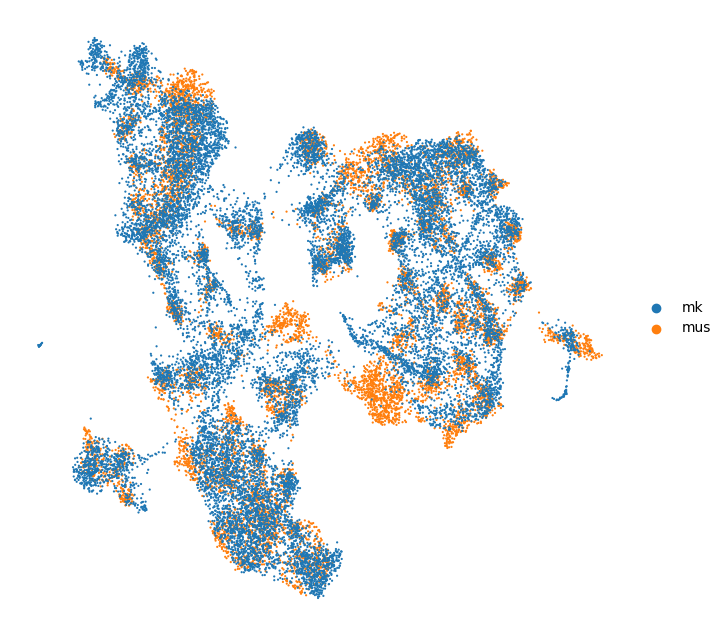

In [38]:
# plot the umaps
figsize(8,8)
sc.pl.umap(adata,color=['species'],legend_loc='right margin',size=10,frameon='',title='',save='umapSpecieCmp_meis2_mk_vs_mus_3.pdf')

In [40]:
adata.uns['plot_cmpMatrix_mk_vs_hu_lovain_2_5'] = plot_cmpMatrix_mk_vs_hu_lovain_0_6

In [42]:
adata.write('./integrated_Ins_and_Tasic_Inhib_final.h5ad')

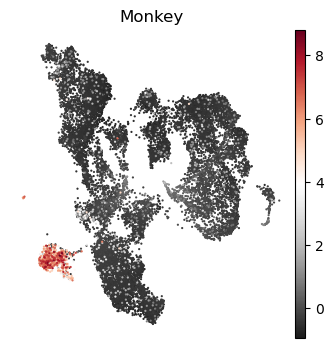

In [43]:
figsize(4,4)
sc.pl.umap(adata[adata.obs['species']=='mk'],color=['MEIS2'],legend_loc='right margin',cmap='RdGy_r',s=10,frameon='',title='Monkey',save='mkMeis2_vs_mus.pdf')

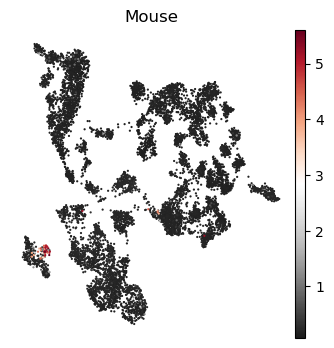

In [44]:
figsize(4,4)
sc.pl.umap(adata[adata.obs['species']=='mus'],color=['MEIS2'],legend_loc='right margin',cmap='RdGy_r',s=10,frameon='',title='Mouse',save='musMeis2_vs_mk.pdf')

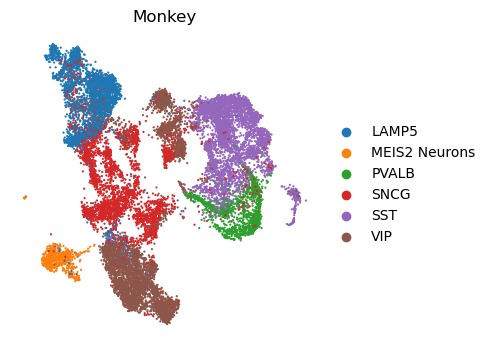

In [48]:
figsize(4,4)
sc.pl.umap(adata[adata.obs['species']=='mk'],color=['inhibType'],legend_loc='right margin',cmap='RdGy_r',s=10,frameon='',title='Monkey',save='mkInhibType.pdf')

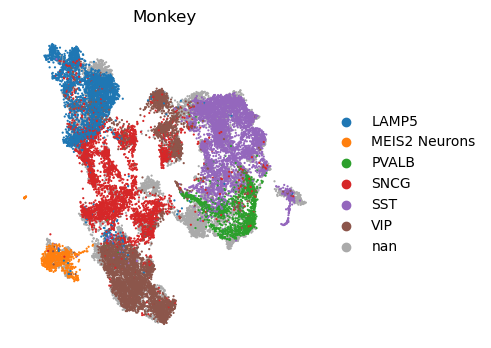

In [60]:
figsize(4,4)
adata.uns['inhibType_colors']=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#aaaaaa']
sc.pl.umap(adata,color=['inhibType'],legend_loc='right margin',cmap='RdGy_r',s=10,frameon='',title='Monkey',save='mkInhibType.pdf')

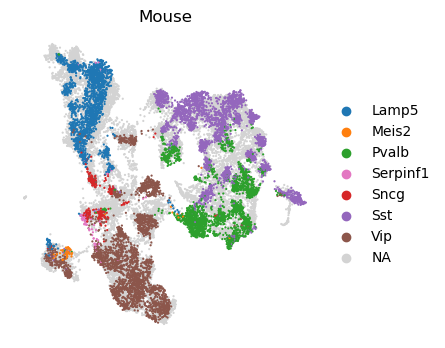

In [68]:
figsize(4,4)
adata.uns['cell_subclass_colors'] = ['#1f77b4', '#ff7f0e', '#2ca02c', '#e377c2', '#d62728', '#9467bd', '#8c564b', '#000000']
sc.pl.umap(adata,color=['cell_subclass'],legend_loc='right margin',cmap='RdGy_r',s=10,frameon='',title='Mouse',save='musInhibType.pdf')